In [9]:
import turicreate

In [19]:
image_train_data = turicreate.SFrame('image_train_data/')
image_test_data = turicreate.SFrame('image_test_data/')

In [11]:
sketch = turicreate.Sketch(image_train_data['label'])
print(sketch)

category_counts = image_train_data['label'].value_counts().sort('count', ascending=False)
print(category_counts)




+------------------+-------+----------+
|       item       | value | is exact |
+------------------+-------+----------+
|      Length      |  2005 |   Yes    |
| # Missing Values |   0   |   Yes    |
| # unique values  |   4   |    No    |
+------------------+-------+----------+

Most frequent items:
+------------+-------+
|   value    | count |
+------------+-------+
|    cat     |  509  |
|    dog     |  509  |
| automobile |  509  |
|    bird    |  478  |
+------------+-------+


+------------+-------+
|   value    | count |
+------------+-------+
|    dog     |  509  |
|    cat     |  509  |
| automobile |  509  |
|    bird    |  478  |
+------------+-------+
[4 rows x 2 columns]



In [13]:
dog_data = image_train_data[image_train_data['label'] == 'dog']
cat_data = image_train_data[image_train_data['label'] == 'cat']
automobile_data = image_train_data[image_train_data['label'] == 'automobile']
bird_data = image_train_data[image_train_data['label'] == 'bird']

print("Dogs:", len(dog_data))
print("Cats:", len(cat_data))
print("Autos:", len(automobile_data))
print("Birds:", len(bird_data))

Dogs: 509
Cats: 509
Autos: 509
Birds: 478


In [14]:
dog_model = turicreate.nearest_neighbors.create(dog_data, 
                                                features=['deep_features'], 
                                                label='id')

Starting brute force nearest neighbors model training.

Validating distance components.

Initializing model data.

Initializing distances.

Done.

In [15]:
cat_model = turicreate.nearest_neighbors.create(cat_data, 
                                                features=['deep_features'], 
                                                label='id')

Starting brute force nearest neighbors model training.

Validating distance components.

Initializing model data.

Initializing distances.

Done.

In [16]:
automobile_model = turicreate.nearest_neighbors.create(automobile_data, 
                                                       features=['deep_features'], 
                                                       label='id')

Starting brute force nearest neighbors model training.

Validating distance components.

Initializing model data.

Initializing distances.

Done.

In [17]:
bird_model = turicreate.nearest_neighbors.create(bird_data, 
                                                 features=['deep_features'], 
                                                 label='id')

Starting brute force nearest neighbors model training.

Validating distance components.

Initializing model data.

Initializing distances.

Done.

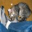

Starting pairwise querying.

+--------------+---------+-------------+--------------+

| Query points | # Pairs | % Complete. | Elapsed Time |

+--------------+---------+-------------+--------------+

| 0            | 1       | 0.196464    | 1.744ms      |

| Done         |         | 100         | 9.321ms      |

+--------------+---------+-------------+--------------+

+-------------+-----------------+-------------------+------+
| query_label | reference_label |      distance     | rank |
+-------------+-----------------+-------------------+------+
|      0      |      16289      | 34.62371920804245 |  1   |
+-------------+-----------------+-------------------+------+
[1 rows x 4 columns]



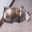

In [43]:
# 取出測試集的第一張圖片
cat_test_image = image_test_data[0:1]

# 顯示這張圖片看看 (選用)
cat_test_image["image"][0].show()

# 使用 cat_model 找出這張圖的「最近鄰居」
# k=1 代表只找最像的那 1 張
result = cat_model.query(cat_test_image, k=1)

# 印出結果
print(result)
result_image = image_train_data[image_train_data['id'] == result["reference_label"][0]]
result_image['image'][0].show()    

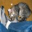

Starting pairwise querying.

+--------------+---------+-------------+--------------+

| Query points | # Pairs | % Complete. | Elapsed Time |

+--------------+---------+-------------+--------------+

| 0            | 1       | 0.196464    | 1.514ms      |

| Done         |         | 100         | 7.364ms      |

+--------------+---------+-------------+--------------+

+-------------+-----------------+--------------------+------+
| query_label | reference_label |      distance      | rank |
+-------------+-----------------+--------------------+------+
|      0      |      16976      | 37.464262878423774 |  1   |
+-------------+-----------------+--------------------+------+
[1 rows x 4 columns]



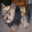

In [44]:
# 取出測試集的第一張圖片
cat_test_image = image_test_data[0:1]

# 顯示這張圖片看看 (選用)
cat_test_image["image"][0].show()

# 使用 cat_model 找出這張圖的「最近鄰居」
# k=1 代表只找最像的那 1 張
result = dog_model.query(cat_test_image, k=1)

# 印出結果
print(result)
result_image = image_train_data[image_train_data['id'] == result["reference_label"][0]]
result_image['image'][0].show()    

In [ ]:
image_test = image_test_data

# 1. 針對測試集的第一張圖片，找出它在 cat_model 中的前 5 個鄰居
cat_neighbors = cat_model.query(image_test[0:1], k=5)

# 2. 找出它在 dog_model 中的前 5 個鄰居
dog_neighbors = dog_model.query(image_test[0:1], k=5)

# 3. 計算這些鄰居距離的平均值
mean_cat_dist = cat_neighbors['distance'].mean()
mean_dog_dist = dog_neighbors['distance'].mean()

print(f"Mean distance to cats: {mean_cat_dist}")
print(f"Mean distance to dogs: {mean_dog_dist}")

# 4. 判斷誰比較近 (這就是 Quiz 的答案)
if mean_cat_dist < mean_dog_dist:
    print("Result: The image is closer to CATS.")
else:
    print("Result: The image is closer to DOGS.")

Starting pairwise querying.

+--------------+---------+-------------+--------------+

| Query points | # Pairs | % Complete. | Elapsed Time |

+--------------+---------+-------------+--------------+

| 0            | 1       | 0.196464    | 1.489ms      |

...

+--------------+---------+-------------+--------------+

| 0            | 1       | 0.196464    | 1.168ms      |

| Done         |         | 100         | 6.872ms      |

+--------------+---------+-------------+--------------+

Mean distance to cats: 36.15573070978294
Mean distance to dogs: 37.77071136184157
Result: The image is closer to CATS.


In [28]:
# 將測試資料拆分為四個類別
image_test_dog = image_test_data[image_test_data['label'] == 'dog']
image_test_cat = image_test_data[image_test_data['label'] == 'cat']
image_test_automobile = image_test_data[image_test_data['label'] == 'automobile']
image_test_bird = image_test_data[image_test_data['label'] == 'bird']

In [30]:
# 查詢四個模型
dog_dog_neighbors = dog_model.query(image_test_dog, k=1)
dog_cat_neighbors = cat_model.query(image_test_dog, k=1)
dog_automobile_neighbors = automobile_model.query(image_test_dog, k=1)
dog_bird_neighbors = bird_model.query(image_test_dog, k=1)

Starting blockwise querying.

max rows per data block: 4348

number of reference data blocks: 24

number of query data blocks: 1

+--------------+---------+-------------+--------------+

...

| Query points | # Pairs | % Complete. | Elapsed Time |

+--------------+---------+-------------+--------------+

| 1000         | 20000   | 4.1841      | 77.922ms     |

| Done         | 478000  | 100         | 93.485ms     |

+--------------+---------+-------------+--------------+

In [31]:
# 建立包含四個距離欄位的 SFrame
dog_distances = turicreate.SFrame({
    'dog-dog': dog_dog_neighbors['distance'],
    'dog-cat': dog_cat_neighbors['distance'],
    'dog-automobile': dog_automobile_neighbors['distance'],
    'dog-bird': dog_bird_neighbors['distance']
})

# 檢查一下表格長相
print(dog_distances.head())

+--------------------+--------------------+--------------------+
|   dog-automobile   |      dog-bird      |      dog-cat       |
+--------------------+--------------------+--------------------+
| 41.957976145712045 | 41.753864730351246 | 36.419607706754384 |
| 46.00213318067789  |  41.3382958924861  | 38.83532688735542  |
| 42.946229069238804 | 38.61575908528905  | 36.97634108541545  |
| 41.68660600484794  | 37.089226995382155 | 34.575007291446106 |
| 39.226966493475835 | 38.27228869398105  | 34.77882479101661  |
| 40.58451176980722  | 39.146208923590486 | 35.11715782924591  |
| 45.10673529610856  | 40.523040105962316 | 40.60958309132649  |
| 41.322114097397645 |  38.1947918392696  | 39.90368673062213  |
| 41.82446549950163  | 40.15671316613143  | 38.067470016821176 |
| 45.49769294011039  | 45.55979626027669  | 42.72587329506032  |
+--------------------+--------------------+--------------------+
+--------------------+
|      dog-dog       |
+--------------------+
| 33.47735903726336  

In [32]:
# 定義判斷函式：如果 'dog-dog' 的距離最小，回傳 1，否則回傳 0
def is_dog_correct(row):
    # 檢查 dog-dog 是否小於其他所有欄位
    if (row['dog-dog'] < row['dog-cat']) and \
       (row['dog-dog'] < row['dog-automobile']) and \
       (row['dog-dog'] < row['dog-bird']):
        return 1
    else:
        return 0

# 使用 apply 應用到每一行，並加總 (sum) 算出正確的總數
correct_count = dog_distances.apply(is_dog_correct).sum()

# 計算總共有多少張狗狗測試圖片
total_dogs = len(image_test_dog)

# 計算準確度
accuracy = correct_count / total_dogs

print(f"Correctly classified dogs: {correct_count}")
print(f"Total dog images: {total_dogs}")
print(f"Accuracy: {accuracy}")

Using default 16 lambda workers.

To maximize the degree of parallelism, add the following code to the beginning of the program:

"turicreate.config.set_runtime_config('TURI_DEFAULT_NUM_PYLAMBDA_WORKERS', 24)"

Note that increasing the degree of parallelism also increases the memory footprint.

Correctly classified dogs: 678
Total dog images: 1000
Accuracy: 0.678
